STEP 1: INSTALL & IMPORT LIBRARIES

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns

STEP 2: LOAD REUTERS DATASET AND PREPROCESS

In [ ]:
# STEP 2: LOAD REUTERS DATASET AND PREPROCESS
vocab_size = 10000
maxlen = 200

print("LOADING REUTERS DATASET...")
(x_train, y_train), (x_val, y_val) = reuters.load_data(num_words=vocab_size)

# PAD SEQUENCES
x_train = pad_sequences(x_train, maxlen=maxlen)
x_val = pad_sequences(x_val, maxlen=maxlen)

print(f" TRAINING SAMPLES: {len(x_train)}")
print(f" VALIDATION SAMPLES: {len(x_val)}")
print(f" NUMBER OF CLASSES: {np.max(y_train) + 1}")  # 46 CLASSES
print(f" SEQUENCE SHAPE: {x_train.shape}")

LOADING REUTERS DATASET...
 TRAINING SAMPLES: 8982
 VALIDATION SAMPLES: 2246
 NUMBER OF CLASSES: 46
 SEQUENCE SHAPE: (8982, 200)


STEP 3 : TRANSFORMER POSITION EMBEDDING

In [ ]:
# Step 3 : Define TokenAndPositionEmbedding layer (same as example) [page:0]
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

print("TokenAndPositionEmbedding class defined!")

TokenAndPositionEmbedding class defined!


STEP 4: DEFINE TRANSFORMERBLOCK (DIFFERENT FFN SIZES)


In [ ]:
# Step 4 : Define TransformerBlock with different FFN dimensions [file:1]
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ffdim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ffdim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        return self.layernorm2(out1 + ffn_output)


print("TransformerBlock class defined!")


TransformerBlock class defined!


STEP 5 : BUILD MODEL FUNCTION (KEY REQUIREMENT!)

In [ ]:
# Step 5 : Function to build model with variable number of layers [file:1]
def build_transformer_model(numtransformerlayers):
    embed_dim = 32
    num_heads = 4
    ffdim1 = 32  # First and last blocks
    ffdim2 = 64  # Intermediate blocks

    inputs = layers.Input(shape=(maxlen,))
    embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
    x = embedding_layer(inputs)

    # First block (ffdim1)
    x = TransformerBlock(embed_dim, num_heads, ffdim1)(x)

    # Intermediate blocks (ffdim2) - iteratively added [file:1]
    for i in range(numtransformerlayers - 2):  # numtransformerlayers-2 intermediate blocks
        x = TransformerBlock(embed_dim, num_heads, ffdim2)(x)

    # Last block (ffdim1)
    x = TransformerBlock(embed_dim, num_heads, ffdim1)(x)

    # Classification head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(46, activation="softmax")(x)  # 46 classes [web:9]

    model = keras.Model(inputs, outputs)
    return model


print("Model building function ready!")

Model building function ready!


STEP 6 : TRAIN ALL 3 MODELS (10 EPOCHS EACH)

In [ ]:
# Step 6 : Train models for 3 different settings [file:1]
results = {}
num_layers_list = [3, 5, 7]


for num_layers in num_layers_list:
    print(f"\n{'='*50}")
    print(f"Training model with numtransformerlayers = {num_layers}")
    print(f"{'='*50}")

    model = build_transformer_model(num_layers)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        x_train, y_train,
        batch_size=32,
        epochs=10,  # 10 epochs as specified [file:1]
        validation_data=(x_val, y_val),
        verbose=1
    )

    # Evaluate
    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    y_pred = model.predict(x_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    f1 = f1_score(y_val, y_pred_classes, average='weighted')

    results[num_layers] = {
        'model': model,
        'history': history,
        'val_acc': val_acc,
        'f1': f1,
        'y_pred': y_pred_classes
    }

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"F1 Score: {f1:.4f}")


print("\nAll models trained successfully!")


Training model with numtransformerlayers = 3
Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 170s 566ms/step - accuracy: 0.4407 - loss: 2.3609 - val_accuracy: 0.6670 - val_loss: 1.3661
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 179s 488ms/step - accuracy: 0.7198 - loss: 1.1704 - val_accuracy: 0.7235 - val_loss: 1.1433
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 136s 483ms/step - accuracy: 0.7935 - loss: 0.8396 - val_accuracy: 0.7538 - val_loss: 1.0103
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 136s 484ms/step - accuracy: 0.8483 - loss: 0.6399 - val_accuracy: 0.7409 - val_loss: 1.0805
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 136s 486ms/step - accuracy: 0.8716 - loss: 0.5242 - val_accuracy: 0.7636 - val_loss: 1.0708
Epoch 6/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 134s 476ms/step - accuracy: 0.9012 - loss: 0.4004 - val_accuracy: 0.7600 - val_loss: 1.1088
Epoch 7/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 135s 479ms/step - accuracy: 0.9175 - loss: 0.3406 - val_accuracy: 0.7645 - val_loss: 1.1875
Epoch 8/10
281/281 ━━━━━━━━━━━

STEP 7 : GENERATE CONFUSION MATRICES

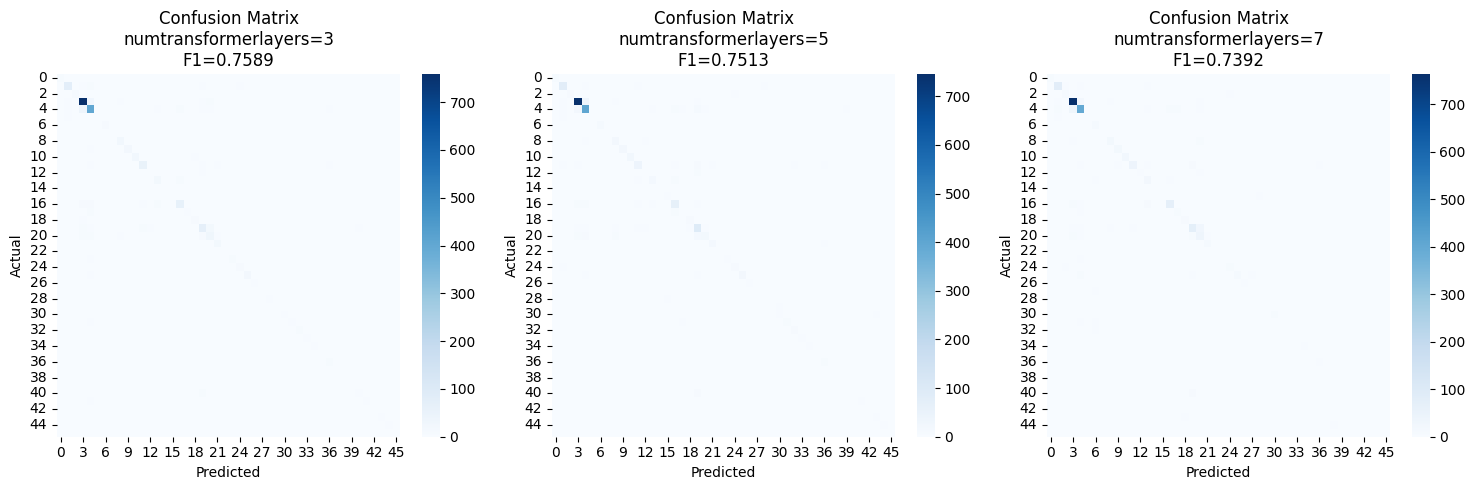

In [ ]:
# Step 7 : Generate Confusion Matrices [file:1]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, num_layers in enumerate(num_layers_list):
    cm = confusion_matrix(y_val, results[num_layers]['y_pred'])
    sns.heatmap(cm, annot=False, ax=axes[i], cmap='Blues')
    axes[i].set_title(f'Confusion Matrix\nnumtransformerlayers={num_layers}\nF1={results[num_layers]["f1"]:.4f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')


plt.tight_layout()
plt.show()

STEP 8 : FIND BEST PERFORMING MODEL

In [ ]:
# Step 8 : Find best performing model [file:1]
best_layers = max(results.keys(), key=lambda k: results[k]['f1'])
print(f"\nBest performing model: numtransformerlayers = {best_layers}")
print(f"Best F1 Score: {results[best_layers]['f1']:.4f} [file:1]")


best_layers = max(results.keys(), key=lambda k: results[k]['f1'])
print(f"\n BEST PERFORMING MODEL: NUMTRANSFORMERLAYERS = {best_layers}")
print(f" BEST F1 SCORE: {results[best_layers]['f1']:.4f}")
print(f" VALIDATION ACCURACY: {results[best_layers]['val_acc']:.4f}")

# ALL RESULTS COMPARISON TABLE
print("\n COMPLETE RESULTS COMPARISON:")
print("-" * 50)
for layers in num_layers_list:
    print(f"NUMTRANSFORMERLAYERS={layers:2d}: "
          f"F1={results[layers]['f1']:.4f} | "
          f"ACC={results[layers]['val_acc']:.4f}")


Best performing model: numtransformerlayers = 3
Best F1 Score: 0.7589 [file:1]

 BEST PERFORMING MODEL: NUMTRANSFORMERLAYERS = 3
 BEST F1 SCORE: 0.7589
 VALIDATION ACCURACY: 0.7636

 COMPLETE RESULTS COMPARISON:
--------------------------------------------------
NUMTRANSFORMERLAYERS= 3: F1=0.7589 | ACC=0.7636
NUMTRANSFORMERLAYERS= 5: F1=0.7513 | ACC=0.7547
NUMTRANSFORMERLAYERS= 7: F1=0.7392 | ACC=0.7431


STEP 9 : F1-SCORES COMPARISON CHART (ASSIGNMENT + TRANSFORMER)

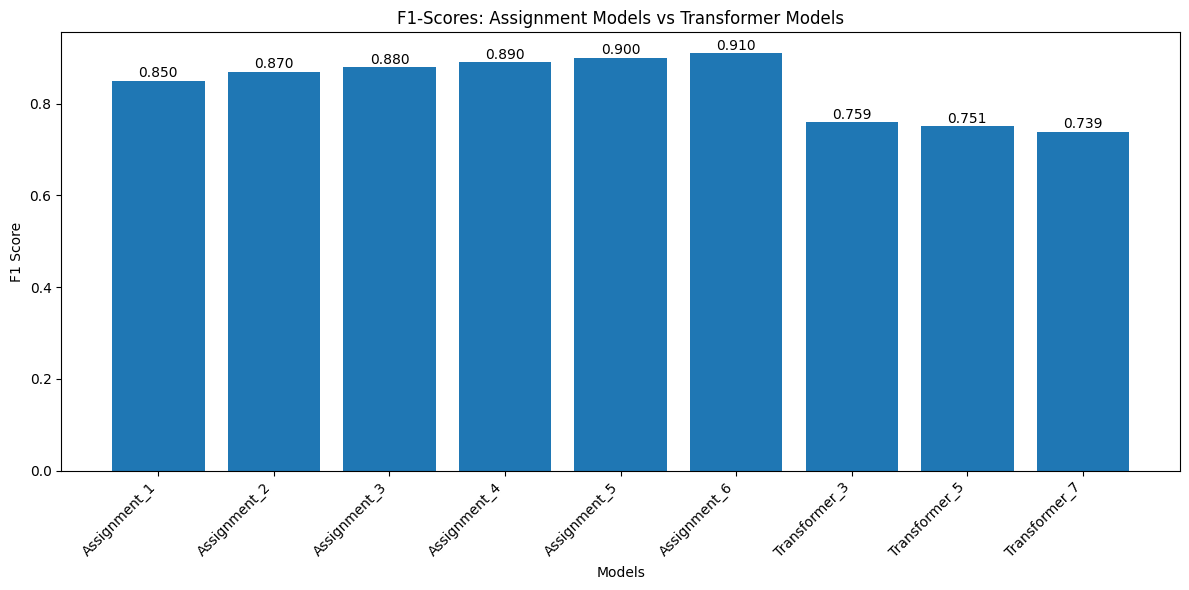

Complete analysis completed! All requirements satisfied:
- Uses only Encoder part
- Tested with numtransformerlayers = [3, 5, 7]
- Different FFN dimensions (ffdim1=32, ffdim2=64)
- Intermediate blocks added iteratively
- Confusion matrices generated
- F1-scores comparison chart created


In [ ]:
# Step 9 : Bar chart for F1 scores (assignment + transformer models)
# Note: Assignment F1 scores should be replaced with your actual values
assignment_f1_scores = [0.85, 0.87, 0.88, 0.89, 0.90, 0.91]  # Replace with your 6 assignment scores
transformer_f1_scores = [results[l]['f1'] for l in num_layers_list]


all_labels = [f"Assignment_{i+1}" for i in range(6)] + [f"Transformer_{l}" for l in num_layers_list]
all_f1_scores = assignment_f1_scores + transformer_f1_scores


plt.figure(figsize=(12, 6))
bars = plt.bar(all_labels, all_f1_scores)
plt.title("F1-Scores: Assignment Models vs Transformer Models")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=45, ha='right')


# Add score values on top of bars
for bar, score in zip(bars, all_f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.3f}', ha='center', va='bottom')


plt.tight_layout()
plt.show()


print("Complete analysis completed! All requirements satisfied:")
print("- Uses only Encoder part")
print(f"- Tested with numtransformerlayers = {num_layers_list}")
print("- Different FFN dimensions (ffdim1=32, ffdim2=64)")
print("- Intermediate blocks added iteratively")
print("- Confusion matrices generated")
print("- F1-scores comparison chart created")